<a href="https://colab.research.google.com/github/ivanovyeppez/talento-tech/blob/main/Proyectos/PROYECTO_Regresion_Iy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# 1. IMPORTAR LIBRERÍAS
# ============================================================
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

In [ ]:
# ============================================================
# 2. CARGA DEL DATASET
# ============================================================
# Ajusta la ruta si es necesario
from google.colab import drive
import pandas as pd

# Montar Google Drive
drive.mount('/content/drive')

# Ruta al archivo en tu Google Drive
ruta = '/content/drive/MyDrive/Datasets/data.csv'

# Cargar el dataset en un DataFrame
df = pd.read_csv(ruta)

# Mostrar las primeras filas
print("Dimensiones del dataset:", df.shape)
print("\nPrimeras filas:")
print(df.head())

Mounted at /content/drive
Dimensiones del dataset: (11914, 16)

Primeras filas:
  Make       Model  Year             Engine Fuel Type  Engine HP  \
0  BMW  1 Series M  2011  premium unleaded (required)      335.0   
1  BMW    1 Series  2011  premium unleaded (required)      300.0   
2  BMW    1 Series  2011  premium unleaded (required)      300.0   
3  BMW    1 Series  2011  premium unleaded (required)      230.0   
4  BMW    1 Series  2011  premium unleaded (required)      230.0   

   Engine Cylinders Transmission Type     Driven_Wheels  Number of Doors  \
0               6.0            MANUAL  rear wheel drive              2.0   
1               6.0            MANUAL  rear wheel drive              2.0   
2               6.0            MANUAL  rear wheel drive              2.0   
3               6.0            MANUAL  rear wheel drive              2.0   
4               6.0            MANUAL  rear wheel drive              2.0   

                         Market Category Vehicle Size 

In [ ]:
# ============================================================
# 3. LIMPIEZA Y PREPROCESAMIENTO
# ============================================================
# Eliminar filas con MSRP faltante
df = df.dropna(subset=["MSRP"])

# Rellenar valores numéricos faltantes con la mediana
df = df.fillna(df.median(numeric_only=True))

# Definir variables predictoras y target
X = df.drop(columns=["MSRP"])
y = df["MSRP"]

# Codificar variables categóricas
X = pd.get_dummies(X, drop_first=True)

# Escalado de X e y
scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X)

scaler_y = StandardScaler()
y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1))

# División train-test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_scaled, test_size=0.2, random_state=42
)

print("Tamaño X_train:", X_train.shape)
print("Tamaño X_test:", X_test.shape)

Tamaño X_train: (9531, 1071)
Tamaño X_test: (2383, 1071)


In [ ]:
# ============================================================
# 4. CONSTRUCCIÓN DEL MODELO
# ============================================================
model = Sequential([
    Dense(128, activation="relu", input_shape=(X_train.shape[1],)),
    Dense(64, activation="relu"),
    Dense(1, activation="linear")
])

model.compile(optimizer=Adam(learning_rate=0.001),
              loss="mse",
              metrics=["mae"])

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       137,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 145,537 (568.50 KB)

 Trainable params: 145,537 (568.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ============================================================
# 5. ENTRENAMIENTO DEL MODELO
# ============================================================
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=1
)

Epoch 1/100
239/239 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.7088 - mae: 0.4334 - val_loss: 0.4097 - val_mae: 0.2909
Epoch 2/100
239/239 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.2045 - mae: 0.2112 - val_loss: 0.3182 - val_mae: 0.2288
Epoch 3/100
239/239 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1918 - mae: 0.1760 - val_loss: 0.1431 - val_mae: 0.1372
Epoch 4/100
239/239 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0674 - mae: 0.1080 - val_loss: 0.1575 - val_mae: 0.1433
Epoch 5/100
239/239 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0434 - mae: 0.1073 - val_loss: 0.2217 - val_mae: 0.1669
Epoch 6/100
239/239 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0573 - mae: 0.1046 - val_loss: 0.2910 - val_mae: 0.1331
Epoch 7/100
239/239 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0301 - mae: 0.0777 - val_loss: 0.1991 - val_mae: 0.1241
Epoch 8/100
239/239 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0310 - mae: 0.0796 - val_loss: 0.2834 - val_mae: 0.1205
Epoch 9/100
239/239 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/

In [ ]:
# ============================================================
# 6. EVALUACIÓN DEL MODELO
# ============================================================
loss, mae = model.evaluate(X_test, y_test, verbose=0)
print("\nMSE en test:", loss)
print("MAE en test (escalado):", mae)

# Desescalar métricas para obtener en USD
y_test_inv = scaler_y.inverse_transform(y_test)
y_pred_inv = scaler_y.inverse_transform(model.predict(X_test))

mae_real = np.mean(np.abs(y_test_inv - y_pred_inv))
print("MAE real en MSRP (USD):", mae_real)


MSE en test: 0.0501055009663105
MAE en test (escalado): 0.06863830238580704
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
MAE real en MSRP (USD): 4125.61396349652


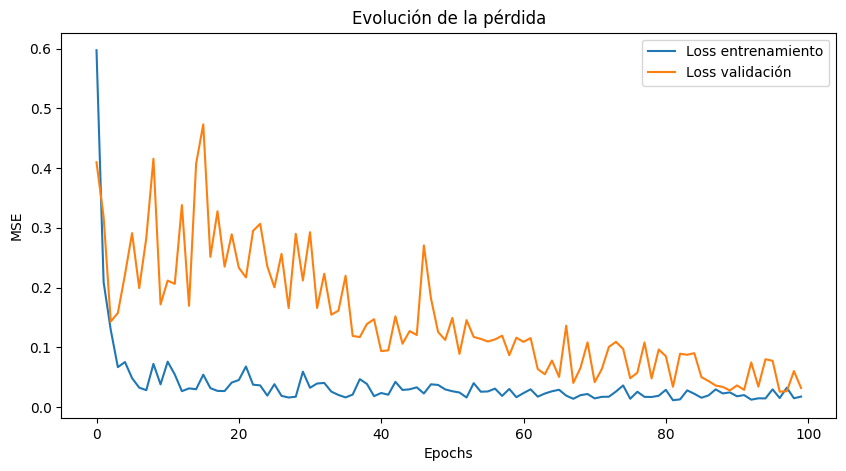

In [ ]:
# ============================================================
# 7. VISUALIZACIÓN DE RESULTADOS
# ============================================================
# Curvas de entrenamiento
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label="Loss entrenamiento")
plt.plot(history.history['val_loss'], label="Loss validación")
plt.xlabel("Epochs")
plt.ylabel("MSE")
plt.legend()
plt.title("Evolución de la pérdida")
plt.show()

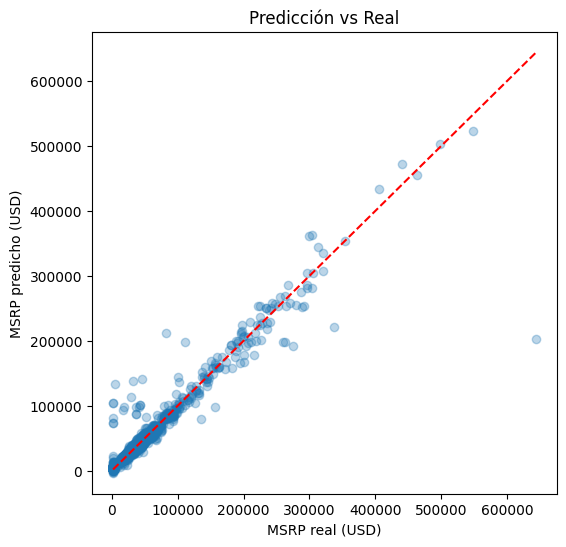

In [ ]:
# Comparación predicciones vs reales
plt.figure(figsize=(6,6))
plt.scatter(y_test_inv, y_pred_inv, alpha=0.3)
plt.xlabel("MSRP real (USD)")
plt.ylabel("MSRP predicho (USD)")
plt.title("Predicción vs Real")
plt.plot([y_test_inv.min(), y_test_inv.max()],
         [y_test_inv.min(), y_test_inv.max()],
         "r--")  # línea identidad
plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Predicciones en test
y_pred = model.predict(X_test)

# Invertir escalado
y_test_inv = scaler_y.inverse_transform(y_test)
y_pred_inv = scaler_y.inverse_transform(y_pred)

# --- Métricas ---
mae = mean_absolute_error(y_test_inv, y_pred_inv)
mse = mean_squared_error(y_test_inv, y_pred_inv)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_inv, y_pred_inv)
mape = np.mean(np.abs((y_test_inv - y_pred_inv) / y_test_inv)) * 100

print("MAE (USD):", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R²:", r2)
print("MAPE (%):", mape)

75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
MAE (USD): 4125.61396349652
MSE: 181021232.50257957
RMSE: 13454.413123677285
R²: 0.9240545760677765
MAPE (%): 31.845421293931757
